# AI Agents Tutorial
작성 : 박광석(모두의연구소, https://www.linkedin.com/in/andkspark) , 2025.03
## 3. Microsoft Autogen AgentChat+ Multiagent

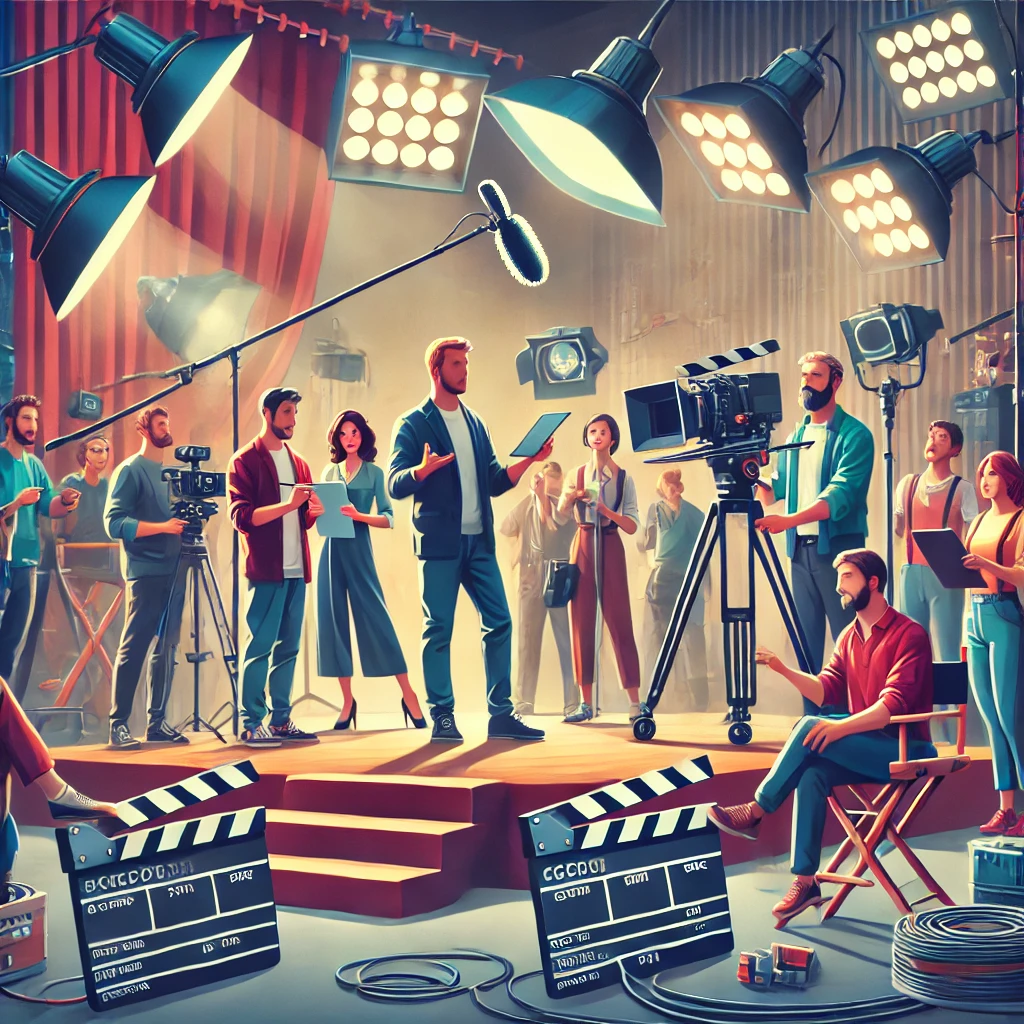



영화의 촬영현장을 생각해봅시다!
영화의 촬영현장을 총괄하는 감독이 있을 거구요, 또 촬영감독, 배우, 조명 스태프, 음향팀, 미술팀, 보조출연자까지 정말 다양한 역할을 가진 사람들이 바쁘게 움직이고 있죠!

이 각각의 사람들은 자신이 맡은 역할에 따라 독립적으로 움직이면서도, 전체 영화라는 공통된 목표를 위해 서로 협력합니다.
각자의 전문성과 정보를 바탕으로 판단을 내리고, 상황에 따라 상호작용하고, 감독의 지시 없이도 알아서 움직이는 장면도 많죠!

이게 바로 **멀티 에이전트 시스템(Multi-Agent System)**의 핵심 아이디어입니다!!!

여기서 각 역할을 맡은 사람들은 각 에이전트입니다.

이 에이전트들은 **자율적(autonomous)**이고, 다른 에이전트들과 **의사소통(communication)**하고, **협력하거나 때론 경쟁(competition)**하기도 하며, 전체 시스템의 목적(= 영화 완성)을 향해 함께 나아갑니다!!!

감독이 모든 걸 일일이 통제하지 않아도, 각 부서가 유기적으로 움직여 하나의 멋진 작품이 만들어지듯, 멀티 에이전트 시스템도 여러 개의 지능적 요소들이 스스로 판단하고 협력하면서 복잡한 문제를 해결해나가는 구조인 거죠!!!

## Multi agent system 예시

사용자가 멀티에이전트 시스템에 "기분전환 겸 따뜻한 바다가 있는 해외로 여행 가고 싶어~" 라고 입력을 하면, 다음과 같은 작업이 일어납니다.

1. 수퍼바이저 에이전트 (Supervisor Agent)
사용자 요청을 분석하여 필요한 작업들을 식별하고, 해당 작업을 적절한 에이전트에 할당합니다.
  
[1] 여행지 탐색  
[2] 일정 확인  
[3] 항공권 예약  
[4] 숙소 예약  
[5] 여행 일정 구성  
[6] 준비물 및 체크리스트 생성  
  
2. 🔎 웹서치 에이전트 (Web Search Agent)
조건: “따뜻한 바다 + 해외 + 기분전환”
결과: 몰디브, 발리, 하와이 등候보 후보지를 수집
사용자 선호와 날씨, 거리 등을 고려해 상위 3개 여행지를 추려냅니다
  
3. 📅 일정 확인 에이전트 (Calendar Agent)
사용자의 캘린더와 연동, 가능한 여행 기간을 탐색합니다. (예: 다음 달 3박 4일 공휴일 포함)
  
4. ✈️ 항공권 에이전트 (Flight Booking Agent)
일정과 여행지 후보를 기반으로 가장 합리적인 항공편을 탐색합니다. 가격, 시간대, 직항 여부 등 고려하여 추천합니다.
  
5. 🏨 숙소 예약 에이전트 (Accommodation Agent)
선택된 여행지에서 일정에 맞는 숙소를 검색합니다. 해변 접근성, 후기 평점, 가격 등을 기준으로 후보를 정리합니다.
  
6. 📋 여행 일정 구성 에이전트 (Itinerary Agent)
지역 명소, 맛집, 액티비티 등을 조사하여 사용자 성향에 맞는 여행 계획 초안을 생성합니다. 아침–점심–저녁 루틴 기반 일별 일정을 제안합니다.
  
7. 🧳 체크리스트/준비물 에이전트 (Checklist Agent)
여행지 특성과 일정에 맞는 준비물을 자동 생성합니다. (여권, 수영복, 선크림 등) 필요한 예약 확인서 및 비자 여부를 체크합니다.
  
8. 🤝 수퍼바이저: 결과 통합 및 사용자 응답을 담당합니다.
각 에이전트가 수집한 정보와 제안을 종합하여 사용자에게 요약된 여행 제안서를 제공합니다
  
9. ✅ 사용자 최종 선택 및 확정
사용자가 마음에 드는 옵션을 선택하면,
선택에 따라 예약 및 후속 조치를 자동으로 진행하게 됩니다. (예: 티켓 발권, 체크리스트 알림 등)
  
이렇게 멀티에이전트 시스템은 사용자의 한마디에, 추천 여행지 + 항공편 + 숙소 + 일정표 + 준비 리스트까지 한 번에 능동적으로 검색하고, 예약할 수 있습니다.
  
예시에서 주목할만한 점은, 모든 과정을 총괄하는 수퍼바이저가 있다! 입니다. 작업을 총괄하며, 세부 분류하고, 기능에 따라 필요한 작업자들을 배치합니다. 이 부분은 구현 시 유저의 오케스트레이션으로 대체되기도 합니다.

##Multi Agent 디자인 패턴

Microsoft는 에이전트간의 협업을 다음과 같은 형태로 분류하였습니다.
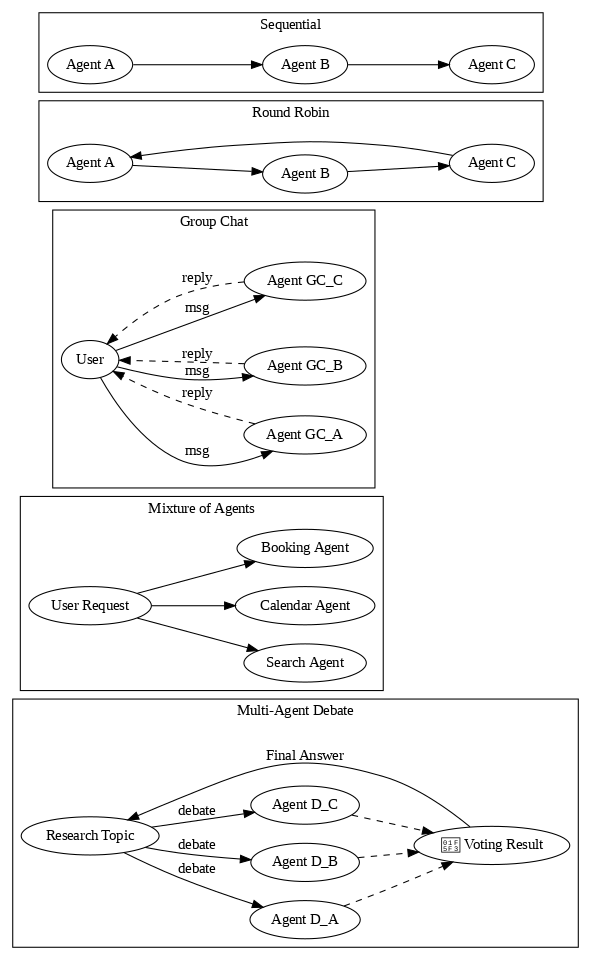
1. Sequential (순차 실행)
에이전트들이 정해진 순서대로 작업을 처리합니다.
각 단계는 이전 에이전트의 출력을 받아 다음 에이전트가 작업을 수행합니다.  
예: Agent A → Agent B → Agent C
  
2. Round Robin (순환 실행)
에이전트들이 정해진 순서에 따라 교대로 작업을 수행합니다.
순환 구조로 반복하며 각 에이전트는 번갈아 가며 의견 또는 작업을 제공합니다.  
예: Agent A → B → C → 다시 A...  

3. Group Chat (그룹 대화형 협업)  
모든 에이전트가 동시에 정보를 공유하며 하나의 대화 공간에서 협업합니다. 서로의 메시지를 참조하며 자유롭게 의견을 주고받는 구조입니다.  
  
4. Mixture of Agents (전문화된 역할 분담)  
각 에이전트가 서로 다른 전문 영역을 맡아 전체 작업을 분담합니다. 병렬 또는 부분 협업 형태로 특정 작업을 효율적으로 수행합니다.  
예: 정보 검색 담당 / 일정 조율 담당 / 예약 담당 등
  
5. Multi-Agent Debate (토론 기반 협업)  
여러 에이전트가 서로 다른 관점을 제시하고 토론을 통해 최적의 해결책을 도출합니다.
투표 또는 평가 메커니즘으로 최종 의사결정을 내리는 구조입니다.


## Multi Agent system 사례
그렇다면, 현재 Multi Agent를 차용한 시스템들에는 어떤것들이 있을지 알아봅시다!


###AI Co-Scientist (2025.02, Google)

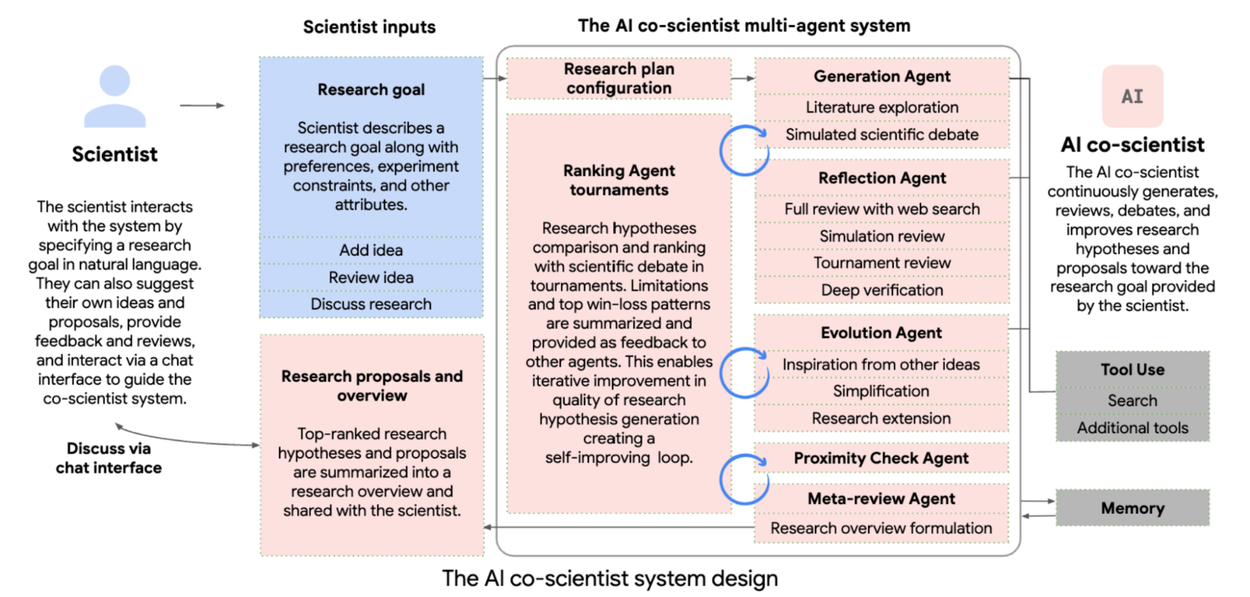


AI Co-Scientist는 과학적 사고 과정을 구조화된 방식으로 구현한 **AI 기반 연구 보조 시스템**입니다. 사용자가 자연어로 연구 목표를 제시하면, 시스템은 이를 바탕으로 관련 가설을 생성하고 점진적으로 발전시켜 나갑니다. 이 시스템은 "생성–토론–진화(generate, debate, evolve)"라는 핵심 원칙을 따르며, 주어진 목표에 따라 가설을 구성한 뒤, 내부 논의와 검토 과정을 거쳐 점차 개선된 형태로 최적의 가설을 도출하는 방식으로 작동합니다.

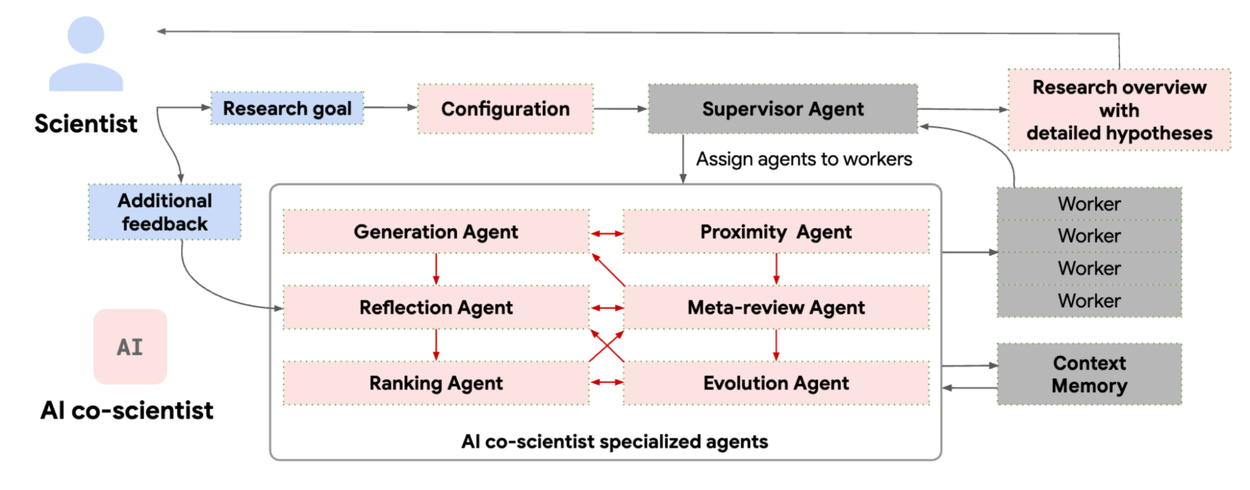

### MD agents (2024.04)

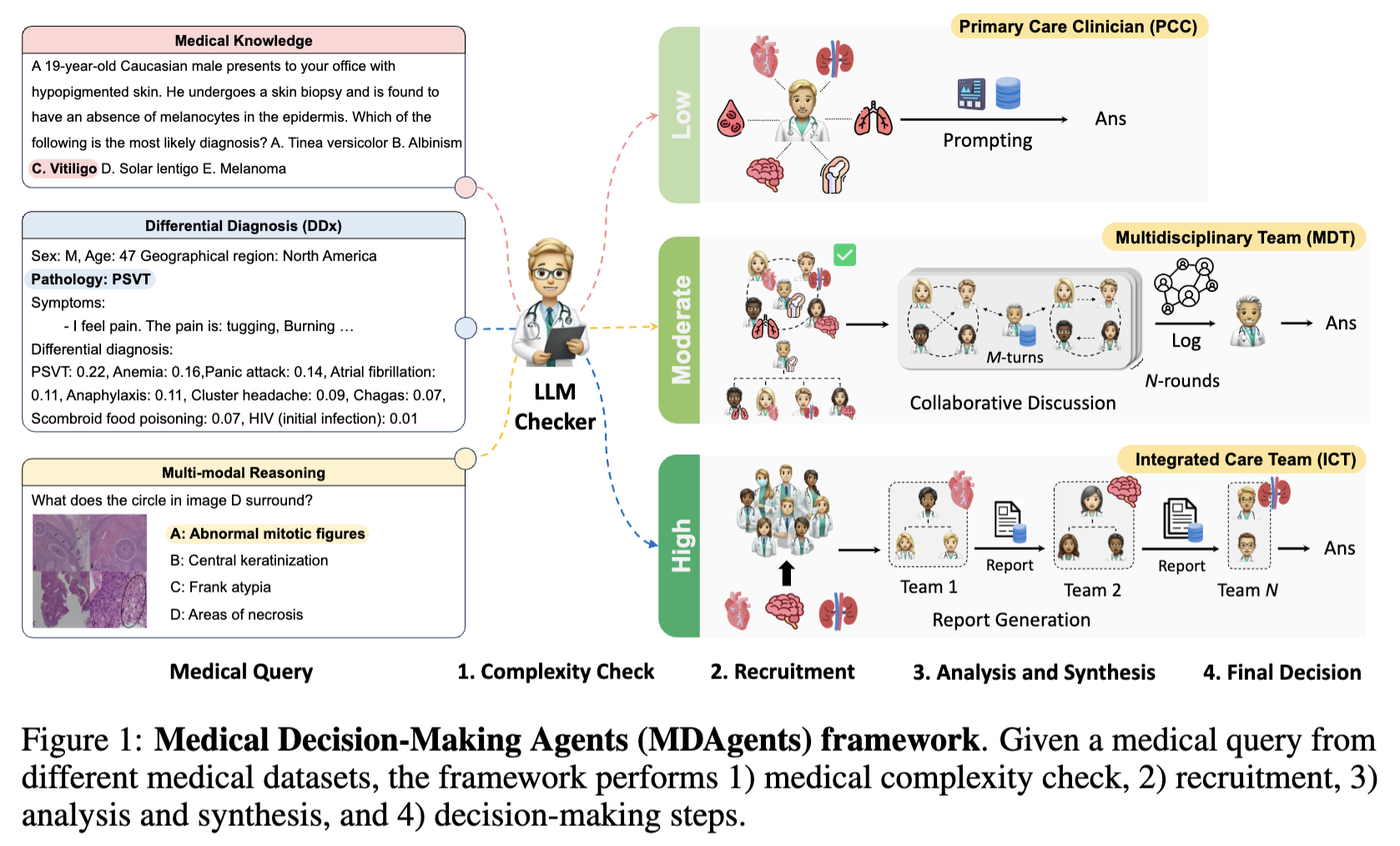

MDAgents는 MIT Media Lab에서 제안한 의료 의사결정용 멀티 에이전트 프레임워크입니다.
의료 작업의 복잡성에 따라 LLM 에이전트에게 단독 또는 그룹 협업 구조를 동적으로 할당하며, 실제 임상 의사결정 과정을 모사합니다. 10개의 실제 의료 지식 및 진단 벤치마크에서 평가된 결과, 최대 4.2% 성능 향상, 그룹 협업 시 평균 11.8% 정확도 향상이라는 성과를 보였습니다.

### VISTA: Visual Integrated System for Tailored Automation in Math Problem Generation Using LLM (2024.10, 모두의연구소)

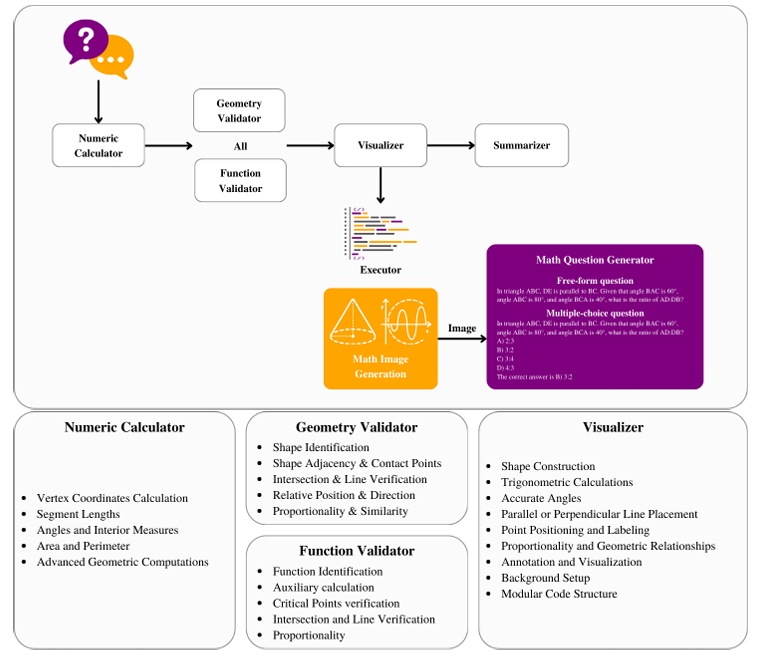

VISTA는 대규모 언어 모델(LLM)을 활용하여 수학 문제와 관련된 시각 자료를 자동으로 생성하는 멀티 에이전트 프레임워크입니다. 이 시스템은 수치 계산, 기하학 검증, 시각화를 담당하는 여러 에이전트들을 통합하여 수학적으로 정확하고 맥락에 맞는 시각 자료를 생성합니다. 기하학과 함수 문제에서 VISTA를 통해 생성된 문제들은 기존 LLM으로 생성된 문제들보다 시각적 유사성 및 텍스트 일관성, 관련성, 유사성 측면에서 우수함을 보였습니다.

# Multi Agent : Autogen 실습 : StockAgent  
삼성전자와 SK하이닉스 주식 성과를 비교해서 투자 관련 참고 의견만 제공

### 구굴 Colab Drive 연결 및 OpenAI key 등록

In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
%cd /content/drive/MyDrive/aiffel/3.rag/4

/content/drive/MyDrive/aiffel/3.rag/4


In [12]:
from dotenv import load_dotenv
import os

load_dotenv("/content/drive/MyDrive/aiffel/env_keys/.env")

print("OPENAI_API_KEY loaded:", os.getenv("OPENAI_API_KEY") is not None)

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")

OPENAI_API_KEY loaded: True


### 주가 갖고오는 프로그램

In [1]:
!pip install pykrx

In [2]:
from pykrx import stock
import pandas as pd
import numpy as np

# def fetch_stock_history(ticker: str, period: str = "2y") -> pd.DataFrame:
#     # period를 간단히 날짜로 변환 (예: 2y → 약 2년 전)
#     end = pd.Timestamp.today().strftime("%Y%m%d")
#     start = (pd.Timestamp.today() - pd.DateOffset(years=2)).strftime("%Y%m%d")
#     df = stock.get_market_ohlcv(start, end, ticker)
#     return df

# data_1 = fetch_stock_history("005930")  # 삼성전자
# data_2 = fetch_stock_history("000660")  # sk 하이닉스

# # 컬럼에 티커 정보를 붙여서 MultiIndex로 만들고 합치기
# data_1_cols = data_1.add_prefix("005930_")
# data_2_cols = data_2.add_prefix("000660_")

# df = pd.concat([data_1_cols, data_2_cols], axis=1)

# print(df.head())

In [3]:
def compute_metrics(df, price_col="Close", risk_free_rate=0.0, freq=252):
    """가격 시계열 df에서 수익률, 변동성, MDD, Sharpe 등을 계산."""
    # 1. 가격 → 일간 수익률 계산
    r = df[price_col].pct_change().dropna()

    # 2. 연간화 수익률, 변동성
    annual_return = r.mean() * freq
    annual_vol = r.std() * np.sqrt(freq)

    # 3. 최대 낙폭(Maximum Drawdown, MDD)
    cum_ret = (1 + r).cumprod()
    cum_max = cum_ret.cummax()
    drawdown = (cum_ret - cum_max) / cum_max
    max_drawdown = drawdown.min()

    # 4. Sharpe ratio (무위험수익률 0 가정)
    excess_return = annual_return - risk_free_rate
    sharpe = excess_return / annual_vol if annual_vol > 1e-8 else np.nan

    # 5. 기하 평균 수익률 (CAGR)
    cagr = cum_ret.iloc[-1] ** (freq / len(r)) - 1

    # 6. 결과 딕셔너리로 반환
    metrics = {
        "annual_return": annual_return,
        "annual_volatility": annual_vol,
        "max_drawdown": max_drawdown,
        "sharpe_ratio": sharpe,
        "cagr": cagr,
        "n_days": len(r)
    }
    return pd.Series(metrics)


In [32]:
# # 툴 역할 함수: df -> 두 종목 메트릭 계산
# def compute_stock_metrics(df: pd.DataFrame):
#     m_005930 = compute_metrics(df.rename(columns={"005930_종가": "Close"}))
#     m_000660 = compute_metrics(df.rename(columns={"000660_종가": "Close"}))
#     return {
#         "005930": m_005930.to_dict(),
#         "000660": m_000660.to_dict(),
#     }

In [15]:
# # 예: 두 종목의 일간 수익률 계산
# returns = df.pct_change().dropna()

# # 예: 각 종목 별로 compute_metrics 적용
# metrics_005930 = compute_metrics(df.rename(columns={"005930_종가": "Close"}))
# metrics_000660 = compute_metrics(df.rename(columns={"000660_종가": "Close"}))

# print(metrics_005930)

annual_return          0.562846
annual_volatility      0.404197
max_drawdown          -0.431663
sharpe_ratio           1.392506
cagr                   0.617825
n_days               483.000000
dtype: float64


In [4]:
# 1) 과거 주가 가져오는 함수
def fetch_stock_history(ticker: str, years: int = 2) -> pd.DataFrame:
    end = pd.Timestamp.today().strftime("%Y%m%d")
    start = (pd.Timestamp.today() - pd.DateOffset(years=years)).strftime("%Y%m%d")
    df = stock.get_market_ohlcv(start, end, ticker)
    return df

In [5]:
# 2) 하나의 종목에 대해 compute_metrics 적용하는 래퍼
def compute_stock_metrics_for_ticker(ticker: str, years: int = 2) -> pd.Series:
    df = fetch_stock_history(ticker, years=years)
    # compute_metrics는 Close 컬럼 기준이라고 가정
    metrics = compute_metrics(df.rename(columns={"종가": "Close"}))
    return metrics

In [6]:
# 3) 두 종목을 한 번에 계산 (decisionAgent에 넘길 payload)
def compute_pair_metrics(t1: str = "005930", t2: str = "000660", years: int = 2):
    m1 = compute_stock_metrics_for_ticker(t1, years=years)
    m2 = compute_stock_metrics_for_ticker(t2, years=years)
    return {
        t1: m1.to_dict(),
        t2: m2.to_dict(),
    }

### Step 0 : 설치와 준비  
Autogen 설치 및 Gemini API 키를 등록하도록 합니다.

In [7]:
!pip install autogen
!pip install -U "autogen-agentchat"
!pip install "autogen-ext[openai]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.3/119.3 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.9/101.9 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.4/331.4 kB 7.2 MB/s eta 0:00:00


In [ ]:
# from google.colab import userdata

# GOOGLE_API_KEY = userdata.get('GEMINI_KEY')

In [8]:
from autogen_agentchat.agents import AssistantAgent
from autogen_agentchat.conditions import TextMentionTermination
from autogen_ext.models.openai import OpenAIChatCompletionClient

### Step 1 : 에이전트 시스템 메세지 작성  
각 에이전트에 적용할 시스템 메세지와 에이전트의 설명을 작성해보겠습니다.  
description 또한 에이전트 선언에 꼭 필요하니, 잘 기억해주세요!  

### Q1. 모델 클라이언트 정의  

In [35]:
# model_client = OpenAIChatCompletionClient(
#     model="gpt-4.1-mini",  # 지금 노트북에서 쓰는 것과 동일하게
#     api_key=OPENAI_API_KEY,
#     base_url="https://api.openai.com/v1",
# )

client_small = OpenAIChatCompletionClient(
    model="gpt-4.1-mini",   # 애널리스트용, 빠른 모델
    api_key=OPENAI_API_KEY,
    base_url="https://api.openai.com/v1",
)

# client_decision = OpenAIChatCompletionClient(
#     model="gpt-4.1",        # 최종 의사결정용, 좀 더 큰 모델
#     api_key=OPENAI_API_KEY,
# )

client_decision = OpenAIChatCompletionClient(
    model="gpt-4.1-mini",   # 애널리스트용, 빠른 모델
    api_key=OPENAI_API_KEY,
    base_url="https://api.openai.com/v1",
)


### Q2. 에이전트 정의  
위에서 선언한 모델 클라이언트를 사용하는 어시스턴트들을 정의해주세요!  
scenario writer, scene planner, storyboard artist 가 필요합니다  

In [36]:
samsung_analyst = AssistantAgent(
    name="SamsungAnalyst",
    model_client=client_small,
    system_message=(
        "너는 삼성전자(005930) 전문 주식 애널리스트다.\n"
        "입력으로 주어지는 것은:\n"
        "1) 오늘 날짜 기준 과거 약 2년치 주가로부터 계산된 정량 지표(metrics)\n"
        "2) 인터넷에서 수집한 최신 뉴스 및 리포트 요약\n\n"
        "metrics에는 annual_return, annual_volatility, max_drawdown, sharpe_ratio, cagr, n_days 등이 포함된다.\n"
        "오직 삼성전자 관점에서만 이 정보를 해석하고, 다음을 한국어로 간결히 작성하라:\n"
        "- 정량 지표에 대한 평가 (수익률/변동성/샤프/최대낙폭 등)\n"
        "- 최근 뉴스/이슈가 향후 실적과 밸류에이션에 주는 영향\n"
        "- 3~6개월 투자 의견 (매수/보유/매도 중 하나, 간단한 근거 포함)\n"
        "숫자는 그대로 활용하되, 과도한 디스클레이머는 쓰지 마라."
    ),
)

skhynix_analyst = AssistantAgent(
    name="HynixAnalyst",
    model_client=client_small,
    system_message=(
        "너는 SK하이닉스(000660) 전문 주식 애널리스트다.\n"
        "입력으로 주어지는 것은:\n"
        "1) 오늘 날짜 기준 과거 약 2년치 주가로부터 계산된 정량 지표(metrics)\n"
        "2) 인터넷에서 수집한 최신 뉴스 및 리포트 요약\n\n"
        "metrics에는 annual_return, annual_volatility, max_drawdown, sharpe_ratio, cagr, n_days 등이 포함된다.\n"
        "오직 SK하이닉스 관점에서만 이 정보를 해석하고, 다음을 한국어로 간결히 작성하라:\n"
        "- 정량 지표에 대한 평가\n"
        "- 최근 뉴스/이슈가 향후 실적과 밸류에이션에 주는 영향\n"
        "- 3~6개월 투자 의견 (매수/보유/매도 중 하나, 간단한 근거 포함)"
    ),
)

In [37]:
news_agent = AssistantAgent(
    name="NewsAgent",
    model_client=client_small,
    system_message=(
        "너는 한국 주식 뉴스 요약 애널리스트다.\n"
        "입력으로 티커(예: 005930)와 회사명, 그리고 검색 결과 텍스트 목록이 주어진다.\n"
        "검색 결과를 바탕으로 해당 종목에 대한 최근 1~3개월 주요 이슈를 간결히 요약하라.\n"
        "요약 형식:\n"
        "- 핵심 이슈 3~5개 (불릿)\n"
        "- 전반적인 톤 (긍정/중립/부정) 한 줄\n"
        "반드시 한국어로 작성하고, 불필요한 각주나 출처 표기는 하지 마라."
    ),
)

In [38]:
decision_agent = AssistantAgent(
    name="DecisionAgent",
    model_client=client_decision,
    system_message=(
        "너는 포트폴리오 매니저다.\n"
        "삼성전자(005930)와 SK하이닉스(000660)의 정량 지표(metrics)와 "
        "각 종목 애널리스트의 리포트를 보고, 두 종목 중 어느 쪽이 더 매력적인지 판단하는 역할이다.\n\n"
        "출력 요구사항:\n"
        "1) 정량 지표 비교 요약 (표 1개: 행=지표, 열=005930/000660)\n"
        "2) 각 애널리스트 리포트의 핵심 포인트 2~3개씩\n"
        "3) 오늘 기준 3~6개월 관점에서의 최종 종합 의견:\n"
        "   - 삼성전자 vs 하이닉스 중 상대적으로 더 선호하는 종목과 이유\n"
        "   - 두 종목 모두에 대한 간단한 리스크 요인 언급\n"
        "4) 반드시 한국어로 작성.\n"
    ),
)


### 뉴스 검색

In [39]:
# !pip install gnews

/usr/lib/python3.12/pathlib.py:404: RuntimeWarning: coroutine 'get_news_report_from_agent' was never awaited
  parsed = [sys.intern(str(x)) for x in rel.split(sep) if x and x != '.']


In [41]:
from gnews import GNews

In [42]:
gnews = GNews(language='ko', country='KR', max_results=5, period='7d')

def search_news_raw(ticker: str, company_name: str, n_results: int = 5) -> list[str]:
    query = f"{company_name} {ticker}"
    articles = gnews.get_news(query)  # 최근 7일 한국어 뉴스 검색[web:75]

    texts: list[str] = []
    for a in articles[:n_results]:
        # title + description을 합쳐서 에이전트에 넘길 텍스트로 사용
        title = a.get("title") or ""
        desc = a.get("description") or ""
        text = (title + " " + desc).strip()
        if text:
            texts.append(text)

    return texts

In [43]:
def build_news_agent_prompt(ticker: str, company_name: str, raw_texts: list[str]) -> str:
    news_text = "\n\n".join(raw_texts) if raw_texts else "관련 뉴스가 거의 없음."

    return (
        f"티커: {ticker}\n"
        f"회사명: {company_name}\n\n"
        "다음은 인터넷/뉴스 검색 결과 텍스트 목록이다:\n"
        f"{news_text}\n\n"
        "이 정보를 바탕으로 지시에 따라 요약하라."
    )


In [44]:
import asyncio

async def get_news_report_from_agent(ticker: str, company_name: str) -> str:
    raw_texts = search_news_raw(ticker, company_name, n_results=5)
    prompt = build_news_agent_prompt(ticker, company_name, raw_texts)
    result = await news_agent.run(task=prompt)
    return result

# # 사용 예시
# result = asyncio.run(get_news_report_from_agent("005930", "삼성전자"))


In [45]:
def build_analyst_prompt_from_news_report(
    ticker: str,
    metrics: dict,
    news_report: str,
) -> str:
    return (
        f"티커: {ticker}\n"
        f"정량 지표(metrics):\n{metrics}\n\n"
        "다음은 NewsAgent가 작성한 최근 1~3개월 뉴스 요약 보고서이다:\n"
        f"{news_report}\n\n"
        "이 정량 지표와 뉴스 요약을 모두 반영해서 분석하라."
    )

#### 뉴스 캐시 유틸 함수 추가

In [53]:
import os
import json

CACHE_DIR = "news_cache"
os.makedirs(CACHE_DIR, exist_ok=True)

def load_news_cache(ticker: str) -> str | None:
    path = os.path.join(CACHE_DIR, f"{ticker}.json")
    if not os.path.exists(path):
        return None
    try:
        with open(path, "r", encoding="utf-8") as f:
            data = json.load(f)
        return data.get("report")
    except Exception:
        return None

def save_news_cache(ticker: str, report: str) -> None:
    path = os.path.join(CACHE_DIR, f"{ticker}.json")
    with open(path, "w", encoding="utf-8") as f:
        json.dump({"ticker": ticker, "report": report}, f, ensure_ascii=False, indent=2)


In [54]:
async def get_news_report_with_cache(ticker: str, company_name: str) -> str:
    # 1) 캐시 체크
    cached = load_news_cache(ticker)
    if cached is not None:
        return cached

    # 2) 캐시 없으면 NewsAgent 호출
    report = await get_news_report_from_agent(ticker, company_name)

    # 3) 결과 저장
    save_news_cache(ticker, report)
    return report


### Q3. 그룹챗 선언  
그룹쳇에는 위에 선언한 세 개의 에이전트가 들어가야 합니다!  
챗 종료를 관리하기 위한 termination을 정의하고 시작해보죠

In [46]:
from autogen_agentchat.teams import RoundRobinGroupChat

In [47]:
termination = TextMentionTermination("TERMINATE")

groupchat = RoundRobinGroupChat(
    [samsung_analyst, skhynix_analyst, decision_agent],
    termination_condition=termination,
)

In [48]:
# 여러 번 그룹챗을 수행할 경우, 꼭 위의 그룹챗 선언 전에 해당 문구를 먼저 실행해주시기 바랍니다
# await group_chat.reset()

### Q4. 스트림 실행하기  
콘솔에서 아래 선언한 스트림을 실행해보세요!  
결과를 result 변수로 받아 추후 작업을 수행할 수 있습니다.

In [55]:
async def run_full_pipeline_with_news_agent(years: int = 2):
    # 1) 정량 지표 계산
    metrics_dict = compute_pair_metrics("005930", "000660", years=years)
    metrics_005930 = metrics_dict["005930"]
    metrics_000660 = metrics_dict["000660"]

    # 2) NewsAgent가 각 종목 뉴스 요약 보고서 작성
    samsung_news_report = await get_news_report_with_cache("005930", "삼성전자")
    await asyncio.sleep(1.5)
    hynix_news_report   = await get_news_report_with_cache("000660", "SK하이닉스")
    await asyncio.sleep(1.5)

    # 3) 애널리스트 프롬프트 구성 (정량 + NewsAgent 보고서)
    samsung_prompt = build_analyst_prompt_from_news_report(
        "005930",
        metrics_005930,
        samsung_news_report,
    )
    hynix_prompt = build_analyst_prompt_from_news_report(
        "000660",
        metrics_000660,
        hynix_news_report,
    )

    samsung_report = await samsung_analyst.run(task=samsung_prompt)
    await asyncio.sleep(1.5)
    hynix_report   = await skhynix_analyst.run(task=hynix_prompt)
    await asyncio.sleep(1.5)

    # 4) DecisionAgent에 모든 정보 전달
    decision_prompt = (
        "다음은 삼성전자/하이닉스의 백테스트 지표, NewsAgent 뉴스 요약, "
        "각 종목 애널리스트 리포트이다.\n\n"
        f"[삼성전자(005930) metrics]\n{metrics_005930}\n\n"
        f"[하이닉스(000660) metrics]\n{metrics_000660}\n\n"
        "[삼성전자 뉴스 요약 (NewsAgent)]\n"
        f"{samsung_news_report}\n\n"
        "[하이닉스 뉴스 요약 (NewsAgent)]\n"
        f"{hynix_news_report}\n\n"
        "[삼성전자 애널리스트 리포트]\n"
        f"{samsung_report}\n\n"
        "[하이닉스 애널리스트 리포트]\n"
        f"{hynix_report}\n\n"
        "위 정보를 바탕으로 요구된 형식대로 최종 결론을 작성하라."
    )

    final_decision = await decision_agent.run(decision_prompt)

    return {
        "metrics": metrics_dict,
        "samsung_news_report": samsung_news_report,  # ← NewsAgent 산출물
        "hynix_news_report": hynix_news_report,      # ← NewsAgent 산출물
        "samsung_report": samsung_report,            # ← 삼성 애널리스트
        "hynix_report": hynix_report,                # ← 하이닉스 애널리스트
        "final_decision": final_decision,            # ← DecisionAgent
    }

In [56]:
result = await run_full_pipeline_with_news_agent(years=2)

print("=== SAMSUNG NEWS (NewsAgent) ===")
print(result["samsung_news_report"])

print("\n=== HYNIX NEWS (NewsAgent) ===")
print(result["hynix_news_report"])

print("\n=== SAMSUNG ANALYST REPORT ===")
print(result["samsung_report"])

print("\n=== HYNIX ANALYST REPORT ===")
print(result["hynix_report"])

print("\n=== FINAL DECISION ===")
print(result["final_decision"])

RateLimitError: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}